In [ ]:
# Jupyter cell: scGPT-embedded bulk + latent-marker selection + LOPO(inner K) Ridge(ILR)
# Strategy:
# 1) 用 scGPT_CP 對「單細胞」做 embedding → latent pseudo-bulk (Sample×CT)
# 2) 在 latent 空間做 per-CT marker selection → 得到 marker latent 維度
# 3) 用 scGPT_CP 對「bulk」做 embedding → 但只用 marker latent 維度來預測 proportion

from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

# ==============================
# macOS / Jupyter patches for scGPT
# ==============================
import os

# 1) macOS 沒有 os.sched_getaffinity 時，scGPT 會噴錯 → 補一個假的
if not hasattr(os, "sched_getaffinity"):
    def _fake_sched_getaffinity(pid):
        return set(range(os.cpu_count() or 1))
    os.sched_getaffinity = _fake_sched_getaffinity

# 2) scGPT 的 embed_data 內部會用 DataLoader(num_workers>0) → macOS 會因為 pickling local Dataset 爆掉
import torch
from torch.utils.data import DataLoader as _OrigDataLoader
import torch.utils.data as _tud

class _PatchedGlobalDataLoader(_OrigDataLoader):
    def __init__(self, *args, **kwargs):
        kwargs["num_workers"] = 0
        super().__init__(*args, **kwargs)

# 替換 torch.utils.data.DataLoader
_tud.DataLoader = _PatchedGlobalDataLoader

# 3) import scgpt 後再把它內部的 DataLoader 也鎖成 num_workers=0
import scgpt as scg
from torch.utils.data import DataLoader as _TorchDL
import scgpt.tasks.cell_emb as _cell_emb

class _PatchedDL_for_scgpt(_TorchDL):
    def __init__(self, *args, **kwargs):
        kwargs["num_workers"] = 0
        super().__init__(*args, **kwargs)

_cell_emb.DataLoader = _PatchedDL_for_scgpt

# ==============================
# PATHS & SETTINGS
# ==============================
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ⚠ 請改成你實際放 continual-pretrained scGPT_CP 的資料夾
#    資料夾裡至少要有: vocab.json, args.json, best_model.pt
SCGPT_MODEL_DIR = Path("../scGPT_CP")

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast",
                  "Myofibroblast","NK","Myeloid","Mast"]
INNER_N_FOLDS      = 5
RIDGE_ALPHA        = 1e-2
MARKER_TOPK_LATENT = 32   # 每個 cell type 選多少 latent 維度當 marker，可調
SEED               = 42

np.random.seed(SEED); random.seed(SEED)

# ==============================
# utils
# ==============================
def need_scanpy():
    import scanpy as sc
    return sc

def parse_sample_from_bulk_col(col: str) -> str:
    """從 bulk 欄位名抓出 sample ID（例如 's5_0' → 's5'）"""
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    """投影到 simplex（元素非負、總和=1）。"""
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR 相關
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]
        H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ==============================
# scGPT helpers
# ==============================
def check_scgpt_model_dir(model_dir: Path):
    req = ["vocab.json", "args.json", "best_model.pt"]
    missing = [f for f in req if not (model_dir / f).exists()]
    if missing:
        raise FileNotFoundError(
            f"scGPT_CP model_dir = '{model_dir}' 缺少檔案: {missing}\n"
            "請依照官方 zero-shot tutorial 下載 continual pre-trained scGPT_CP model，\n"
            "解壓縮後放到這個資料夾底下，確保有 vocab.json / args.json / best_model.pt。"
        )

def embed_cells_with_scgpt(
    adata,
    model_dir: Path,
    gene_col: str = "Gene Symbol",
    batch_size: int = 64,
    emb_key: str = "X_scGPT",
):
    """
    對單細胞 AnnData 做 scGPT_CP embedding，結果存在 adata.obsm[emb_key].
    不改動 adata.X（仍然保留原本 counts / logcounts）。
    """
    sc = need_scanpy()
    check_scgpt_model_dir(model_dir)

    # 確保 var 裡有 gene_col
    if gene_col not in adata.var.columns:
        adata.var[gene_col] = adata.var_names.astype(str)

    print(">>> Embedding TRAIN single cells with scGPT_CP ...")
    emb_adata = scg.tasks.embed_data(
        adata,
        model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
    )
    # 把 latent 搬回原 adata（obs 順序應該一致）
    adata.obsm[emb_key] = np.asarray(emb_adata.obsm["X_scGPT"], dtype=np.float32)

def pseudobulk_latent_by_sample_ct(
    adata,
    ct_col: str,
    sample_col: str,
    emb_key: str = "X_scGPT",
) -> pd.DataFrame:
    """
    在 scGPT latent 空間裡做 pseudo-bulk：
    - 輸入: adata.obsm[emb_key] (n_cells × d)
    - 輸出: latent 維度 × (Sample|CT)
    """
    if emb_key not in adata.obsm:
        raise KeyError(f"AnnData.obsm['{emb_key}'] 不存在，請先跑 embed_cells_with_scgpt。")

    X_lat = np.asarray(adata.obsm[emb_key])  # n_cells × d
    d = X_lat.shape[1]

    obs = adata.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices

    cols, names = [], []
    for (s, ct), idx in groups.items():
        idx = np.asarray(idx)
        Xi = X_lat[idx]  # n_group_cells × d
        cols.append(Xi.mean(axis=0).ravel())
        names.append(f"{s}|{ct}")

    feat_names = np.array([f"scgpt_feat_{i}" for i in range(d)], dtype=str)
    return pd.DataFrame(np.column_stack(cols), index=feat_names, columns=names)

def latent_marker_union(
    pb_latent: pd.DataFrame,
    topk_per_ct: int,
    ct_order: list[str],
) -> list[str]:
    """
    在 latent pseudo-bulk (latent_dim × Sample|CT) 上做 per-CT marker selection。
    做法跟你原本的 stratified_marker_union 一樣，只是「gene → latent dim」：
    - 對每個 CT:
        * 計算該 CT 的 mean activation（跨所有 Sample 的 column）
        * 計算其他 CT 的平均
        * score = log2(CT_mean / rest_mean)
      取 score topk 的 latent_dim；最後做 union。
    """
    # 從 col name 提取 CT
    cts = sorted({c.split("|", 1)[1] for c in pb_latent.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]

    # mean_all: 每個 latent dim 在所有 column 的平均
    mean_all = pb_latent.mean(axis=1) + 1e-9

    selected = set()
    for ct in order:
        cols = [c for c in pb_latent.columns if c.split("|", 1)[1] == ct]
        if not cols:
            continue
        m_ct = pb_latent[cols].mean(axis=1)  # latent_dim × 1
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts) - 1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9)).sort_values(ascending=False)
        selected.update(score.index[:topk_per_ct])

    return list(selected)

def embed_bulk_with_scgpt(
    bulk_tr_raw: pd.DataFrame,
    bulk_te_raw: pd.DataFrame,
    model_dir: Path,
    gene_col: str = "Gene Symbol",
    batch_size: int = 64,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    使用 scGPT_CP pretrained model 對 bulk train/test 做 zero-shot embedding。
    - bulk_*_raw: genes × samples, index = gene symbols, columns = sample IDs
    - 回傳: Btr, Bte 皆為 (features × samples) 的 DataFrame, index= scgpt_feat_i
    """
    sc = need_scanpy()
    check_scgpt_model_dir(model_dir)

    ad_bulk_tr = sc.AnnData(bulk_tr_raw.T.copy())
    ad_bulk_te = sc.AnnData(bulk_te_raw.T.copy())

    for ad_b in (ad_bulk_tr, ad_bulk_te):
        if gene_col not in ad_b.var.columns:
            ad_b.var[gene_col] = ad_b.var_names.astype(str)

    print(">>> Embedding bulk TRAIN with scGPT_CP ...")
    emb_tr = scg.tasks.embed_data(
        ad_bulk_tr,
        model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
    )
    print(">>> Embedding bulk TEST with scGPT_CP ...")
    emb_te = scg.tasks.embed_data(
        ad_bulk_te,
        model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
    )

    Xtr = np.asarray(emb_tr.obsm["X_scGPT"])
    Xte = np.asarray(emb_te.obsm["X_scGPT"])

    assert Xtr.shape[0] == bulk_tr_raw.shape[1], "train bulk sample 數不一致"
    assert Xte.shape[0] == bulk_te_raw.shape[1], "test bulk sample 數不一致"

    feat_names = np.array([f"scgpt_feat_{i}" for i in range(Xtr.shape[1])], dtype=str)

    Btr = pd.DataFrame(
        Xtr.T,
        index=feat_names,
        columns=bulk_tr_raw.columns.astype(str),
    )
    Bte = pd.DataFrame(
        Xte.T,
        index=feat_names,
        columns=bulk_te_raw.columns.astype(str),
    )
    return Btr, Bte

# ==============================
# load data
# ==============================
sc_ = need_scanpy()
ad_tr = sc_.read_h5ad(AD_TRAIN_PATH)
ad_te = sc_.read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充

bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# ==============================
# 單細胞：scGPT latent embedding（用來找 latent markers）
# ==============================
# 確保有 gene_col
if "Gene Symbol" not in ad_tr.var.columns:
    ad_tr.var["Gene Symbol"] = ad_tr.var_names.astype(str)

# CELLTYPE_COL / Sample / Patient 必須存在
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs:
        CELLTYPE_COL = "cell_type"
    else:
        raise KeyError("missing cell-type column in train adata.obs")

if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

embed_cells_with_scgpt(ad_tr, SCGPT_MODEL_DIR, gene_col="Gene Symbol", batch_size=64, emb_key="X_scGPT")

# ==============================
# bulk：scGPT latent embedding（feature 空間）
# ==============================
print(">>> Using scGPT_CP zero-shot embeddings for bulk features ...")
Btr, Bte = embed_bulk_with_scgpt(
    bulk_tr_raw,
    bulk_te_raw,
    SCGPT_MODEL_DIR,
    gene_col="Gene Symbol",
    batch_size=64,
)

B_all  = Btr   # latent_features × n_train
B_test = Bte   # latent_features × n_test

# ==============================
# train truth 對齊
# ==============================
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
sample_to_patient = (
    ad_tr.obs[["Sample","Patient"]]
    .drop_duplicates()
    .set_index("Sample")["Patient"]
    .astype(str)
)

col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK")
                        for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER)
H  = helmert_basis(Kc)

# ==============================
# LOPO + inner K-fold（ilr_inv per fold → mean in simplex）
# ==============================
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

# 統計 latent dim 被選為 marker 的次數（跨所有 outer × inner）
latent_marker_counter = Counter()

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer:
        continue

    others = [p for p in patients_all if p != p_test]
    if not others:
        continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # inner-train 病人的單細胞（含 scGPT latent）
        mask_inner = ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)
        ad_inner = ad_tr[mask_inner].copy()
        if ad_inner.n_obs < 10:
            continue

        # latent pseudo-bulk (latent_dim × Sample|CT)
        pb_latent = pseudobulk_latent_by_sample_ct(
            ad_inner,
            ct_col=CELLTYPE_COL,
            sample_col="Sample",
            emb_key="X_scGPT",
        )

        # per-CT latent markers
        latent_markers = latent_marker_union(
            pb_latent,
            topk_per_ct=MARKER_TOPK_LATENT,
            ct_order=TARGET_ORDER,
        )

        # 統計一下有多少 latent 維度被選到
        latent_marker_counter.update(latent_markers)

        # markers 必須同時存在於 bulk latent feature 裡
        features_used = pd.Index(latent_markers, dtype=str).intersection(B_all.index)
        if len(features_used) < 10:
            # markers 太少就 skip 這個 inner fold
            continue

        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2:
            continue

        X_tr_sg    = B_all.loc[features_used, tr_cols_inner].T
        X_te_train = B_all.loc[features_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[features_used, B_test.columns].T

        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # outer-test train samples
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ==============================
# 看一下 latent 有沒有 cell-type markers
# ==============================
print("\n=== scGPT latent marker 使用情況（跨所有 outer×inner） ===")
print(f"總共有 {len(B_all.index)} 個 latent 維度 (scgpt_feat_*)")
print(f"其中有 {len(latent_marker_counter)} 個維度至少被選為一次 marker")
print("Top 20 最常被選為 marker 的 latent 維度：")
for feat, cnt in latent_marker_counter.most_common(20):
    print(f"  {feat}: {cnt} folds")

unused_latents = [f for f in B_all.index if f not in latent_marker_counter]
print(f"\n有 {len(unused_latents)} 個 latent 維度從未被當成任何 cell type 的 marker（在這個 LOPO 設定下）。")

# ==============================
# 訓練集評估
# ==============================
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([
    simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0))
    for c in cols_eval
])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean())
per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | scGPT_CP bulk embeddings "
      "+ latent markers only | ilr_inv-per-fold → mean (simplex) ===")
print(f"Using scGPT_CP model at: {SCGPT_MODEL_DIR}")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge with scGPT_CP bulk embeddings (latent markers only)")
plt.tight_layout()
plt.show()

# ==============================
# 真 TEST 聚合
# ==============================
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) — scGPT_CP bulk embedding (latent markers only) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_scgptcp_bulk_latentmarkers_ridge.csv")


>>> Embedding TRAIN single cells with scGPT_CP ...
scGPT - INFO - match 7532/7725 genes in vocabulary of size 60697.


Embedding cells:  42%|████▏     | 211/506 [3:05:37<25:33:42, 311.94s/it] 

>>> Using scGPT_CP zero-shot embeddings for bulk features ...
>>> Embedding bulk TRAIN with scGPT_CP ...
scGPT - INFO - match 7532/7725 genes in vocabulary of size 60697.


Embedding cells: 100%|██████████| 1/1 [00:05<00:00,  5.61s/it]

>>> Embedding bulk TEST with scGPT_CP ...
scGPT - INFO - match 7532/7725 genes in vocabulary of size 60697.



Embedding cells: 100%|██████████| 1/1 [00:08<00:00,  8.94s/it]


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — LOPO + inner K-fold | scGPT_CP bulk embeddings | ilr_inv-per-fold → mean (simplex) ===
Using scGPT_CP model at: ../scGPT_CP
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0499
Per-CT RMSE:
T                0.0880
B                0.0565
Endothelial      0.0259
Fibroblast       0.0272
Plasmablast      0.0664
Myofibroblast    0.0283
NK               0.0670
Myeloid          0.0474
Mast             0.0420


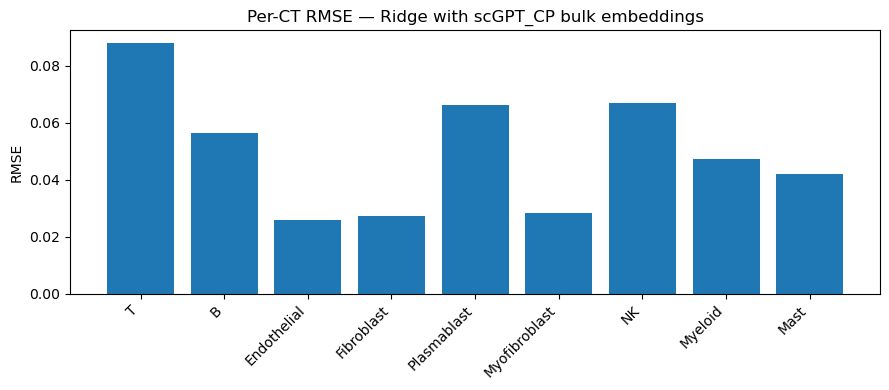


=== TEST PREDICTIONS (simplex, sum=1 per sample) — scGPT_CP bulk embedding ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.582052  0.065372     0.037024    0.087631     0.024333       0.049080   
s5_1  0.536925  0.067289     0.031366    0.097798     0.025344       0.054042   
s5_2  0.535334  0.094431     0.038306    0.076161     0.017550       0.057102   
s5_3  0.551716  0.074211     0.037070    0.083735     0.013702       0.058259   
s5_4  0.577689  0.071658     0.036921    0.083667     0.021656       0.045797   

            NK   Myeloid      Mast  
s5_0  0.094620  0.027042  0.032846  
s5_1  0.130167  0.034223  0.022845  
s5_2  0.120458  0.034402  0.026256  
s5_3  0.121671  0.035130  0.024506  
s5_4  0.097704  0.035829  0.029078  


In [2]:
# Jupyter cell: scGPT-embedded bulk + LOPO(inner K) Ridge(ILR)
# Strategy: use scGPT_CP zero-shot embeddings for bulk features
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
from pathlib import Path
import numpy.typing as npt


# ==== macOS / Jupyter patches for scGPT ====
import os

# 1) macOS 沒有 os.sched_getaffinity，scGPT 會呼叫 → 先補一個假的
if not hasattr(os, "sched_getaffinity"):
    def _fake_sched_getaffinity(pid):
        # 回傳所有 CPU 的 index，模擬 Linux 版本
        return set(range(os.cpu_count() or 1))
    os.sched_getaffinity = _fake_sched_getaffinity

# 2) scGPT 在 embed_data 裡會用 DataLoader + num_workers>0 → 在 macOS 會觸發 pickling error
import torch
from torch.utils.data import DataLoader as _OrigDataLoader
import torch.utils.data as _tud

class _PatchedDataLoader(_OrigDataLoader):
    def __init__(self, *args, **kwargs):
        # 無論他傳什麼 num_workers，全部強制改成 0
        kwargs["num_workers"] = 0
        super().__init__(*args, **kwargs)

# 替換全域 DataLoader，之後 scGPT 內部用到的就是這個版本
_tud.DataLoader = _PatchedDataLoader

# ==== 接下來才能 import scgpt ====
import scgpt as scg

## ==== 接下來才能 import scgpt ====
import scgpt as scg

# 再 patch 一次：把 scgpt.tasks.cell_emb 裡的 DataLoader 也鎖成 num_workers=0
from torch.utils.data import DataLoader as _TorchDL
import scgpt.tasks.cell_emb as _cell_emb

class _PatchedDL_for_scgpt(_TorchDL):
    def __init__(self, *args, **kwargs):
        kwargs["num_workers"] = 0
        super().__init__(*args, **kwargs)

# 直接覆蓋掉 cell_emb 模組內的 DataLoader 符號
_cell_emb.DataLoader = _PatchedDL_for_scgpt

warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== scGPT_CP pretrained model folder =====
# ⚠ 請改成你實際放 continual-pretrained scGPT_CP 的資料夾
SCGPT_MODEL_DIR = Path("../scGPT_CP")

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

np.random.seed(SEED); random.seed(SEED)

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    """原本的單細胞前處理：normalize_total + log1p，用來做 pseudobulk + marker 選取。"""
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    """
    對 ad.X 做 pseudobulk（基因 × Sample|CT），這裡仍然是 gene expression。
    """
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    """對 pseudobulk (genes × Sample|CT) 做 ComBat，batch=Sample."""
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    """
    原本的 per-CT TopK gene selection：還是 gene-level marker（沒有動）。
    """
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== scGPT helpers =====
def check_scgpt_model_dir(model_dir: Path):
    req = ["vocab.json", "args.json", "best_model.pt"]
    missing = [f for f in req if not (model_dir / f).exists()]
    if missing:
        raise FileNotFoundError(
            f"scGPT_CP model_dir = '{model_dir}' 缺少檔案: {missing}\n"
            "請依照官方 zero-shot tutorial 下載 continual pre-trained scGPT_CP model，\n"
            "解壓縮後放到這個資料夾底下，確保有 vocab.json / args.json / best_model.pt。"
        )

def embed_bulk_with_scgpt(bulk_tr_raw: pd.DataFrame,
                          bulk_te_raw: pd.DataFrame,
                          model_dir: Path,
                          gene_col: str = "gene_symbol",
                          batch_size: int = 64) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    使用 scGPT_CP pretrained model 對 bulk train/test 做 zero-shot embedding。
    - bulk_*_raw: genes × samples, index = gene symbols, columns = sample IDs
    - 回傳: Btr, Bte 皆為 (features × samples) 的 DataFrame
    """
    import scgpt as scg
    sc = need_scanpy()

    check_scgpt_model_dir(model_dir)

    # 建立 AnnData：cells=bulk samples, genes = rows
    ad_bulk_tr = sc.AnnData(bulk_tr_raw.T.copy())
    ad_bulk_te = sc.AnnData(bulk_te_raw.T.copy())

    # gene_col 存放 gene 名（對齊官方 example 裡的 gene_col="Gene Symbol"）
    for ad_b in (ad_bulk_tr, ad_bulk_te):
        ad_b.var[gene_col] = ad_b.var_names.astype(str)

    print(">>> Embedding bulk TRAIN with scGPT_CP ...")
    emb_tr = scg.tasks.embed_data(
        ad_bulk_tr,
        model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
    )
    print(">>> Embedding bulk TEST with scGPT_CP ...")
    emb_te = scg.tasks.embed_data(
        ad_bulk_te,
        model_dir,
        gene_col=gene_col,
        batch_size=batch_size,
    )

    # 官方說 embedding 存在 obsm["X_scGPT"]
    Xtr = np.asarray(emb_tr.obsm["X_scGPT"])
    Xte = np.asarray(emb_te.obsm["X_scGPT"])

    assert Xtr.shape[0] == bulk_tr_raw.shape[1], "train bulk sample 數不一致"
    assert Xte.shape[0] == bulk_te_raw.shape[1], "test bulk sample 數不一致"

    feat_names = np.array([f"scgpt_feat_{i}" for i in range(Xtr.shape[1])], dtype=str)

    Btr = pd.DataFrame(
        Xtr.T,
        index=feat_names,
        columns=bulk_tr_raw.columns.astype(str),
    )
    Bte = pd.DataFrame(
        Xte.T,
        index=feat_names,
        columns=bulk_te_raw.columns.astype(str),
    )
    return Btr, Bte

# ===== load =====
sc = need_scanpy()
ad_tr = sc.read_h5ad(AD_TRAIN_PATH)
ad_te = sc.read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充

bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# ===== train sc preprocess（單細胞：只用來選 gene marker）=====
preprocess_sc(ad_tr)

# ===== 用 scGPT_CP 對 bulk 做 zero-shot embedding（取代 CP10k+winsor+asinh）=====
print(">>> Using scGPT_CP zero-shot embeddings for bulk features ...")
Btr, Bte = embed_bulk_with_scgpt(bulk_tr_raw, bulk_te_raw, SCGPT_MODEL_DIR, gene_col="gene_symbol", batch_size=64)

B_all  = Btr   # features × n_train
B_test = Bte   # features × n_test

# ===== train truth 對齊 =====
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: continue

    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 train 單細胞選 marker（還是 gene-level）
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_inner.n_obs < 10: continue

        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)

        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        # genes_used：落在 bulk gene set（因為 B_all 是 scGPT latent，不再用 genes_used 過濾 B_all）
        # 這裡 markers 主要用於後續分析（如果你想限制 bulk 的 gene 子集，可以再延伸）
        # 現在 B_all/B_test 已經是 scGPT latent，所以這裡不再基於 markers 過濾 features
        # 如果你還是想用 markers 控制 features，可以將 scGPT latent 換成 gene space 版本

        # 這一版：直接用所有 scGPT features
        features_used = B_all.index
        if len(features_used) < 20: continue

        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_tr_sg    = B_all.loc[features_used, tr_cols_inner].T
        X_te_train = B_all.loc[features_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[features_used, B_test.columns].T

        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估 =====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | scGPT_CP bulk embeddings | ilr_inv-per-fold → mean (simplex) ===")
print(f"Using scGPT_CP model at: {SCGPT_MODEL_DIR}")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge with scGPT_CP bulk embeddings")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合 =====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) — scGPT_CP bulk embedding ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_scgptcp_bulk_ridge.csv")


In [5]:
from scgpt import gene_recovery

recon = gene_recovery.recover_gene_expression(
    adata_bulk,
    model_dir=SCGPT_MODEL_DIR,
    gene_col="gene_symbol",
    batch_size=32
)

recovered_matrix = recon.layers["X_rec"]  # 還原後的 sample × gene


ImportError: cannot import name 'gene_recovery' from 'scgpt' (/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/scgpt/__init__.py)

Found 7 genes with zero variance.
Found 4 genes with zero variance.
Found 4 genes with zero variance.
Found 4 genes with zero variance.
Found 7 genes with zero variance.
Found 4 genes with zero variance.
Found 4 genes with zero variance.

=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===
Joint preprocess: CP10k + winsor(True, q=0.995) + asinh(True, c=1.0)
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0483
Per-CT RMSE:
T                0.0968
B                0.0636
Endothelial      0.0250
Fibroblast       0.0285
Plasmablast      0.0292
Myofibroblast    0.0305
NK               0.0781
Myeloid          0.0431
Mast             0.0396


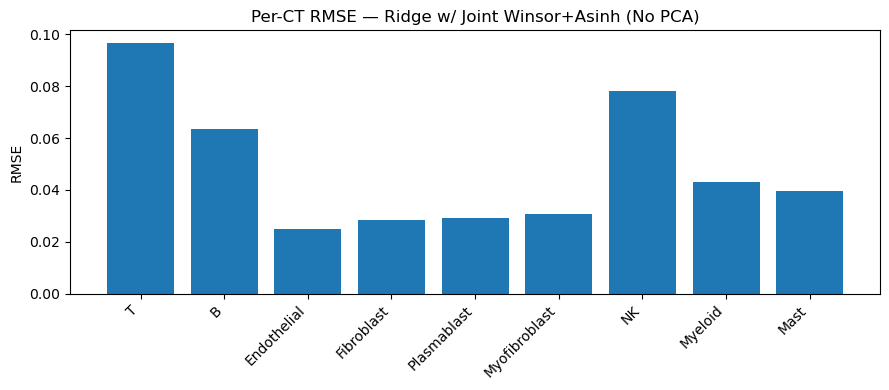


=== TEST PREDICTIONS (simplex, sum=1 per sample) ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.493318  0.118910     0.030481    0.059270     0.074546       0.072495   
s5_1  0.564595  0.108701     0.031518    0.079406     0.012512       0.057652   
s5_2  0.530348  0.138831     0.035556    0.046878     0.036867       0.073886   
s5_3  0.542429  0.113300     0.031477    0.071634     0.024547       0.062718   
s5_4  0.557654  0.132943     0.034261    0.064105     0.018862       0.061454   

            NK   Myeloid      Mast  
s5_0  0.094749  0.035754  0.020477  
s5_1  0.089064  0.026621  0.029930  
s5_2  0.058145  0.059046  0.020444  
s5_3  0.095242  0.031449  0.027205  
s5_4  0.064580  0.039031  0.027110  


In [ ]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)
# ---- Marker selection only: exclude these patients ----
EXCLUDE_PATIENTS = {"P4"}   # 只影響取 marker，不影響訓練/預測樣本
MIN_CELLS_FOR_MARKERS = 10          # 取 marker 的最少細胞數門檻
from lightgbm import LGBMRegressor

LGB_PARAMS = dict(
    learning_rate=0.05,
    n_estimators=800,       # 可再調
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=0.0,
    random_state=SEED,
    n_jobs=-1,
)

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene_pairwise(Btr: pd.DataFrame, Bte: pd.DataFrame, q: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    joint = pd.concat([Btr, Bte], axis=1)
    up = joint.quantile(q, axis=1)
    return Btr.clip(lower=0.0, upper=up, axis=0), Bte.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)
ad_te = need_scanpy().read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")
# sample -> patient（train）
sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

# 排除：UNK + 不在 truth 中 + EXCLUDE_PATIENTS
# 只排除 UNK 与不在 truth 的列；P4 先保留（用于外部验证）
keep_cols = [
    c for c in B_all.columns
    if col_to_patient_train[c] != "UNK" and c in T_all.index
]

B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# containers（train eval）
preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}

# containers（real test）
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer:
        continue

    others = [p for p in patients_all if p != p_test]

    # 训练候选病人：排除 EXCLUDE_PATIENTS（例如 P4）
    others_no_excl = [p for p in others if str(p) not in EXCLUDE_PATIENTS]
    if len(others_no_excl) < 2:
        # 没有足够的训练病人就跳过这个 outer（或按需降折数/改策略）
        continue

    K_inner = min(INNER_N_FOLDS, len(others_no_excl))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others_no_excl)
    
    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())  # 这里已经不含 P4 了

        # 只用 inner-train 病人的单细胞取 marker（不含 P4）
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin({str(p) for p in in_tr_pats})].copy()
        if ad_inner.n_obs < MIN_CELLS_FOR_MARKERS:
            continue

        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        genes_used = pd.Index(markers, dtype=str).intersection(B_all.index).intersection(B_test.index)
        if len(genes_used) < 20:
            continue

        # 训练矩阵仅来自 in_tr_pats（不含 P4）
        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2:
            continue

        X_tr_sg    = B_all.loc[genes_used, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used, B_test.columns].T

        # ===== Train on ILR (Ridge + LGBM) =====
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        # Ridge
        ridge = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        ridge.fit(X_tr_sg, z_in_tr)

        # LGBM
        lgbm  = MultiOutputRegressor(LGBMRegressor(**LGB_PARAMS))
        lgbm.fit(X_tr_sg, z_in_tr)

        # ===== Predict outer-test（train）=====
        z_pred_train_r = ridge.predict(X_te_train)
        z_pred_train_l = lgbm.predict(X_te_train)

        y_pred_train_r = ilr_inv(z_pred_train_r, H)
        y_pred_train_l = ilr_inv(z_pred_train_l, H)

        # 單純形上平均（先各自投影到單純形，再取均值，再投影一次）
        y_pred_train_r = np.vstack([simplex_proj(row) for row in y_pred_train_r])
        y_pred_train_l = np.vstack([simplex_proj(row) for row in y_pred_train_l])
        y_pred_train   = 0.5 * (y_pred_train_r + y_pred_train_l)
        y_pred_train   = np.vstack([simplex_proj(row) for row in y_pred_train])

        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # ===== Predict REAL test =====
        z_pred_real_r = ridge.predict(X_te_real)
        z_pred_real_l = lgbm.predict(X_te_real)

        y_pred_real_r = ilr_inv(z_pred_real_r, H)
        y_pred_real_l = ilr_inv(z_pred_real_l, H)

        y_pred_real_r = np.vstack([simplex_proj(row) for row in y_pred_real_r])
        y_pred_real_l = np.vstack([simplex_proj(row) for row in y_pred_real_l])
        y_pred_real   = 0.5 * (y_pred_real_r + y_pred_real_l)
        y_pred_real   = np.vstack([simplex_proj(row) for row in y_pred_real])

        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 此 outer 的 train 外測聚合
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===")
print(f"Joint preprocess: CP10k + winsor({GLOBAL_WINSORIZE}, q={GLOBAL_WINSOR_Q}) + asinh({GLOBAL_ASINH}, c={GLOBAL_ASINH_C})")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge w/ Joint Winsor+Asinh (No PCA)")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合：ilr_inv-per-fold → mean in simplex（跨所有 outer×inner）=====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_joint_noPCA_ridge.csv")


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===
Joint preprocess: CP10k + winsor(True, q=0.995) + asinh(True, c=1.0)
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0465
Per-CT RMSE:
T                0.0916
B                0.0642
Endothelial      0.0245
Fibroblast       0.0255
Plasmablast      0.0185
Myofibroblast    0.0293
NK               0.0771
Myeloid          0.0455
Mast             0.0422


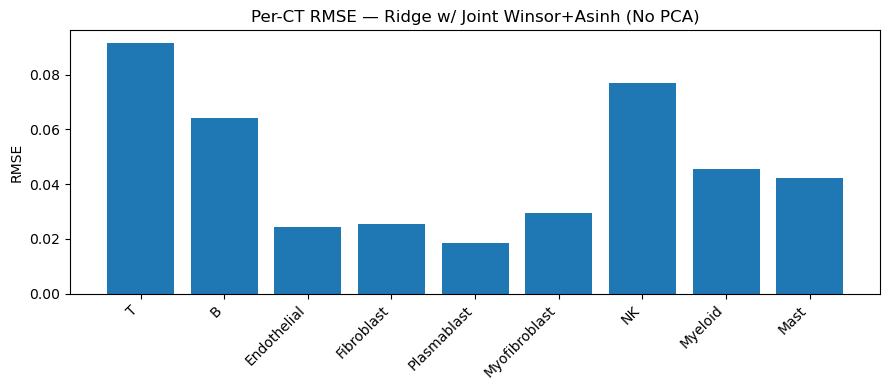


=== TEST PREDICTIONS (simplex, sum=1 per sample) ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.467712  0.131354     0.029881    0.062614     0.043104       0.075080   
s5_1  0.499361  0.134342     0.029345    0.079165     0.005716       0.058068   
s5_2  0.482146  0.175244     0.033943    0.044999     0.017513       0.072851   
s5_3  0.499737  0.123073     0.030314    0.076459     0.013358       0.063717   
s5_4  0.495386  0.161591     0.032018    0.064845     0.008489       0.061922   

            NK   Myeloid      Mast  
s5_0  0.136447  0.039529  0.014279  
s5_1  0.150192  0.026212  0.017599  
s5_2  0.099035  0.062733  0.011535  
s5_3  0.139592  0.033764  0.019986  
s5_4  0.113335  0.045431  0.016982  


In [ ]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene_pairwise(Btr: pd.DataFrame, Bte: pd.DataFrame, q: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    joint = pd.concat([Btr, Bte], axis=1)
    up = joint.quantile(q, axis=1)
    return Btr.clip(lower=0.0, upper=up, axis=0), Bte.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)
ad_te = need_scanpy().read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# containers（train eval）
preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}

# containers（real test）
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: continue

    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 train 單細胞選 marker
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_inner.n_obs < 10: continue

        # pseudobulk → ComBat（batch=Sample）
        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)

        # per-CT TopK union markers
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        # genes_used：落在 joint 前處理後的 train/test 交集
        genes_used = pd.Index(markers, dtype=str).intersection(B_all.index).intersection(B_test.index)
        if len(genes_used) < 20: continue

        # 準備矩陣（samples×genes_used），**不做 PCA**
        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_tr_sg    = B_all.loc[genes_used, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used, B_test.columns].T

        # Ridge on ILR
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 此 outer 的 train 外測聚合
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===")
print(f"Joint preprocess: CP10k + winsor({GLOBAL_WINSORIZE}, q={GLOBAL_WINSOR_Q}) + asinh({GLOBAL_ASINH}, c={GLOBAL_ASINH_C})")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge w/ Joint Winsor+Asinh (No PCA)")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合：ilr_inv-per-fold → mean in simplex（跨所有 outer×inner）=====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_joint_noPCA_ridge.csv")


In [15]:
from scripts.save import save_props_as_index_wide_fixed

# 使用方式（沿用你原本的變數）
out_path = "../workflow/outputs/result_3/pred_props.csv"
_ = save_props_as_index_wide_fixed(
    df_test_pred=df_test_pred,
    out_path=out_path,
)

# （可選）檢視前幾列/欄
print("\n(saved preview)")
print(pd.read_csv(out_path, nrows=5).iloc[:, :8])


[OK] Wrote to: ../workflow/outputs/result_3/pred_props.csv

(saved preview)
   Unnamed: 0        index      s5_0      s5_1      s5_2      s5_3      s5_4  \
0           0            T  0.493318  0.564595  0.530348  0.542429  0.557654   
1           1  Endothelial  0.030481  0.031518  0.035556  0.031477  0.034261   
2           2   Fibroblast  0.059270  0.079406  0.046878  0.071634  0.064105   
3           3  Plasmablast  0.074546  0.012512  0.036867  0.024547  0.018862   
4           4            B  0.118910  0.108701  0.138831  0.113300  0.132943   

       s6_0  
0  0.611161  
1  0.032049  
2  0.092899  
3  0.006673  
4  0.060059  
